# 08 - Risk analysis: VaR, Expected Shortfall, VaR backtest, Monte Carlo

- **VaR / ES:** 1-day horizon, 95% and 99%, on daily strategy returns. Three methods: historical, parametric normal and Student-t. The comparison shows how much a normal assumption understates fat tails.
- **Kupiec test:** a rolling one-year historical VaR forecast, with exceptions counted against the expected rate. This mirrors the PD backtest in the credit module.
- **Monte Carlo:** a stationary block bootstrap of real daily returns, giving one-year outcomes and drawdowns.

Why not the credit module's Gaussian one-factor model? Default dependence is unobserved, but strategy returns are observed directly, so resampling them keeps their real fat tails and volatility clustering.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))
import pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 200)
import run_pipeline as rp
from src import config
T, F = config.TABLES_DIR, config.FIGURES_DIR
SYMBOL = config.SYMBOL
# False (default): display the outputs saved by scripts/run_pipeline.py.
# True re-computes the stage. Do NOT re-run 'validation' or 'test' casually:
# validation resets the experiment log and every test run adds a TEST row.
RUN_STAGE = False
def show(name, **kw):
    display(Markdown(f"**{name}**")); display(pd.read_csv(T / name, **kw))
def fig(name):
    display(Image(filename=str(F / name)))
def results(section):
    return json.loads((config.REPORTS_DIR / "results.json").read_text()).get(section, {})

In [2]:
if RUN_STAGE:
    rp.stage_risk(SYMBOL)

In [3]:
show('risk_var_es_daily.csv')

**risk_var_es_daily.csv**

,series,level,method,VaR,ES
0,strategy,0.95,historical,0.017155,0.028061
1,strategy,0.95,parametric normal,0.016174,0.019648
2,strategy,0.95,"Student-t (df=1.2) - fit degenerate, n/a",NaN,NaN
3,strategy,0.99,historical,0.035309,0.045396
4,strategy,0.99,parametric normal,0.021840,0.024657
5,strategy,0.99,"Student-t (df=1.2) - fit degenerate, n/a",NaN,NaN
6,buy_and_hold,0.95,historical,0.036502,0.051077
7,buy_and_hold,0.95,parametric normal,0.039392,0.049648
8,buy_and_hold,0.95,Student-t (df=3.6),0.037822,0.058700
9,buy_and_hold,0.99,historical,0.061395,0.075933


In [4]:
show('risk_kupiec.csv')

**risk_kupiec.csv**

,level,window_days,days,exceptions,expected,exception_rate,lr_stat,p_value
0,0.95,250,754,33,37.70,0.043767,0.642705,0.422733
1,0.99,250,754,9,7.54,0.011936,0.268901,0.604070


In [5]:
show('risk_bootstrap_mc.csv')

**risk_bootstrap_mc.csv**

,paths,median_one_year_return,p_loss_over_year,one_year_VaR95,one_year_ES95,median_max_drawdown,p5_max_drawdown
0,5000,-0.59974,1.0,0.701698,0.722846,-0.603783,-0.70298


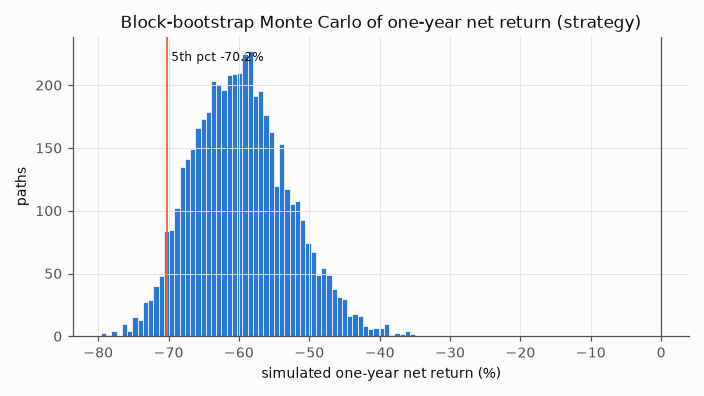

In [6]:
fig('risk_mc_one_year.png')

**Interpretation:** see the matching section of `reports/final_report.md`, written from these outputs.